<a href="https://colab.research.google.com/github/DinhThanh-Dat/ThucHanhDeepLearning/blob/main/Baitaptuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CÀI ĐẶT CNN

##Nạp thư viện

In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

##Đọc dữ liệu MNIST

In [3]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [4]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
print(X_test.shape)

print('Number pf classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number pf classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


##Trực quan hóa 10 ảnh đầu tiên

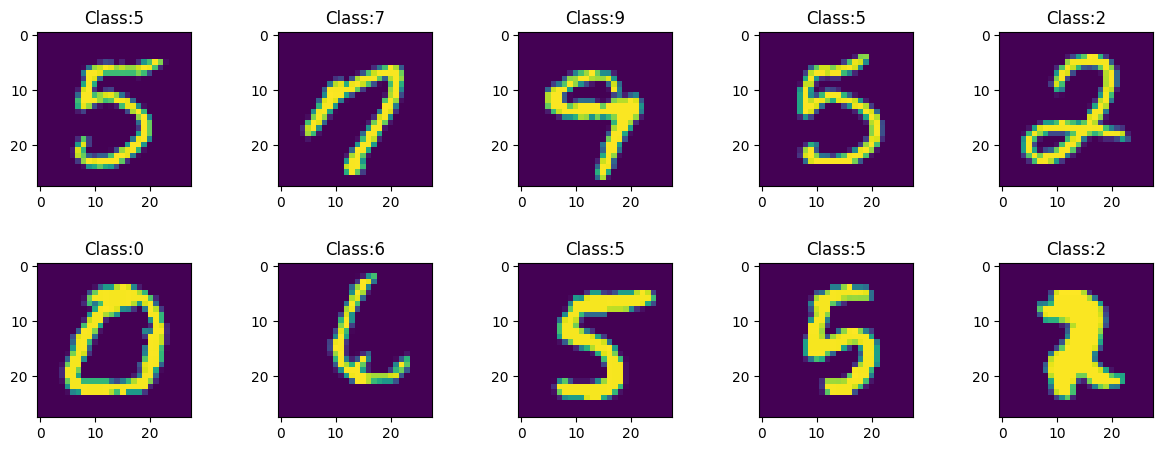

In [5]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

##Chuyển giá trị nhãn thành one-hot encoding

In [6]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

##Xây dựng mô hình CNN

In [7]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3,), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

##Huấn luyện mô hình CNN

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1,verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8357 - loss: 0.6558 - val_accuracy: 0.9080 - val_loss: 0.3217
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9258 - loss: 0.2592 - val_accuracy: 0.9355 - val_loss: 0.2358
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9446 - loss: 0.1892 - val_accuracy: 0.9435 - val_loss: 0.1933
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9597 - loss: 0.1453 - val_accuracy: 0.9535 - val_loss: 0.1543
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9692 - loss: 0.1143 - val_accuracy: 0.9570 - val_loss: 0.1332
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9751 - loss: 0.0958 - val_accuracy: 0.9630 - val_loss: 0.1205
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9789 - loss: 0.0828 - val_accuracy: 0.9670 - val_loss: 0.1157
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9817 - loss: 0.0706 - val_a

##Đánh giá mô hình CNN

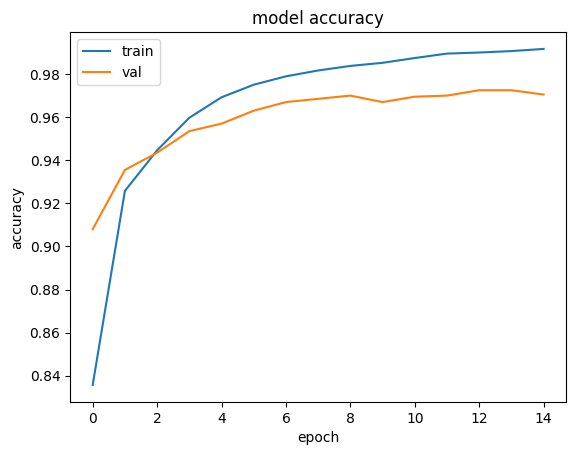

In [9]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

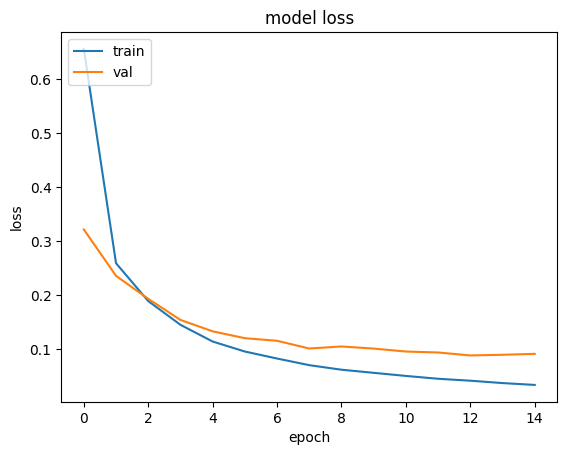

In [10]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

##Đánh giá mô hình CNN thử nghiệm trên tập test

In [11]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 8ms/step - accuracy: 0.9758 - loss: 0.0779
Test loss: 0.07788532972335815
Test accuracy: 0.9757975935935974


##Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[3.0526160e-05 1.3531536e-04 9.9741626e-01 3.2776172e-06 1.6273535e-11
  1.0030192e-06 2.4106842e-03 2.2226130e-13 2.9074240e-06 8.3516950e-11]]
2 2


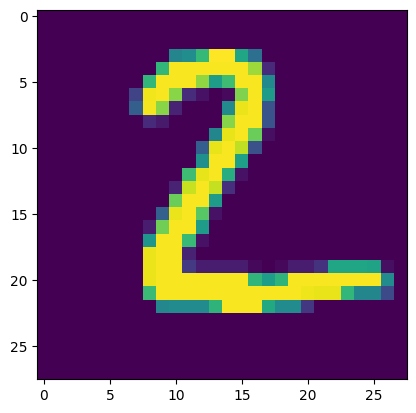

In [12]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

##Lưu tham số mô hình CNN

In [14]:
model.save_weights('cnn.weights.h5')

##Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[[3.4845172e-05 9.9604625e-01 3.4819511e-04 3.6846013e-05 1.6281233e-03
  3.6096564e-05 2.0339774e-04 1.5145402e-03 1.4185497e-04 9.7395441e-06]]
1 1


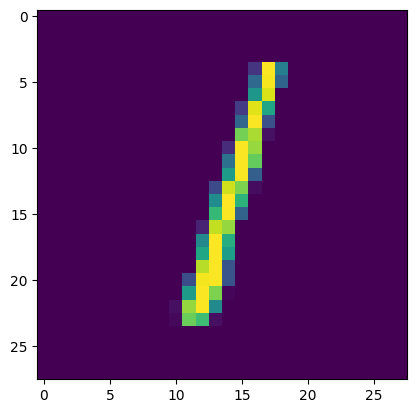

In [15]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32,kernel_size=(3,3,), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

#Bài Tập

#Bài 1

## Nhận dạng ảnh trên bộ dữ liệu CIFAR-10 với CNN

### 1. Nạp dữ liệu và Chuẩn hóa (CIFAR-10 đầy đủ 10 lớp)

In [21]:
# Tải bộ dữ liệu CIFAR-10 tích hợp sẵn trong TensorFlow
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape, y_test.shape)

# Tên của 10 lớp đối tượng trong bộ dữ liệu CIFAR-10
class_names_cifar10 = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']

num_classes_cifar10 = 10
input_shape_cifar10 = (32, 32, 3) # Ảnh màu kích thước 32x32 với 3 kênh RGB

# Chuẩn hóa giá trị pixel từ đoạn [0, 255] về đoạn [0, 1] để hội tụ nhanh hơn
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Chuyển giá trị nhãn từ số nguyên (0-9) thành cấu trúc One-Hot Encoding
y_train_one_hot_cifar10 = keras.utils.to_categorical(y_train, num_classes_cifar10)
y_test_one_hot_cifar10 = keras.utils.to_categorical(y_test, num_classes_cifar10)

Kích thước tập huấn luyện: (50000, 32, 32, 3) (50000, 1)
Kích thước tập kiểm tra: (10000, 32, 32, 3) (10000, 1)


### 2. Trực quan hóa dữ liệu (Xem thử 10 ảnh đầu tiên từ CIFAR-10)

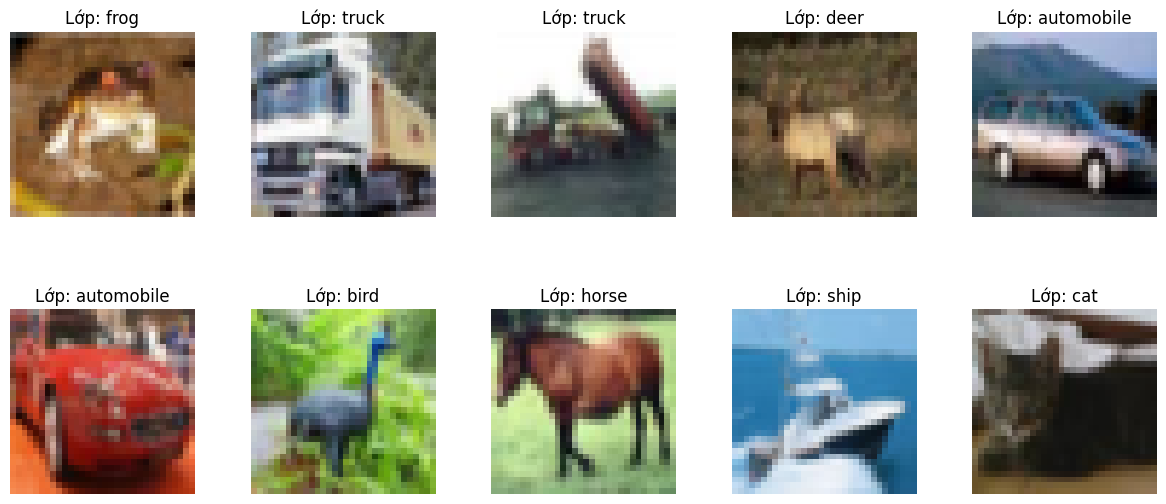

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i])
    # y_train[i][0] lấy ra giá trị số nguyên của nhãn
    ax[i].title.set_text(f"Lớp: {class_names_cifar10[y_train[i][0]]}")
    ax[i].axis('off') # Ẩn hệ trục tọa độ cho đẹp

plt.subplots_adjust(hspace=0.5)
plt.show()

### 3. Xây dựng Kiến trúc mô hình CNN cho CIFAR-10

In [23]:
model_cifar10 = Sequential()
model_cifar10.add(Input(shape=input_shape_cifar10))

# Tầng chập 1 & Max Pooling
model_cifar10.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_cifar10.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_cifar10.add(MaxPool2D(pool_size=(2, 2)))
model_cifar10.add(Dropout(0.25))

# Tầng chập 2 & Max Pooling
model_cifar10.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model_cifar10.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_cifar10.add(MaxPool2D(pool_size=(2, 2)))
model_cifar10.add(Dropout(0.25))

# Làm phẳng ma trận để đưa vào tầng kết nối đầy đủ (Fully Connected Layer)
model_cifar10.add(Flatten())
model_cifar10.add(Dense(units=512, activation='relu'))
model_cifar10.add(Dropout(0.5))
model_cifar10.add(Dense(units=num_classes_cifar10, activation='softmax')) # Hàm kích hoạt Softmax để phân lớp

# Hiển thị cấu trúc tóm tắt của mô hình
model_cifar10.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Cấu hình và Huấn luyện mô hình

In [24]:
model_cifar10.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Thực hiện huấn luyện trong 20 epochs với kích thước lô (batch_size) là 64
model_fit_cifar10 = model_cifar10.fit(X_train, y_train_one_hot_cifar10,
                                      batch_size=64,
                                      epochs=20,
                                      validation_split=0.1,
                                      verbose=1)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 293ms/step - accuracy: 0.4197 - loss: 1.5765 - val_accuracy: 0.5596 - val_loss: 1.2285
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 297ms/step - accuracy: 0.5779 - loss: 1.1781 - val_accuracy: 0.6570 - val_loss: 0.9752
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 207s 294ms/step - accuracy: 0.6431 - loss: 1.0135 - val_accuracy: 0.6908 - val_loss: 0.8978
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 273s 310ms/step - accuracy: 0.6824 - loss: 0.9035 - val_accuracy: 0.7344 - val_loss: 0.7642
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 292ms/step - accuracy: 0.7067 - loss: 0.8298 - val_accuracy: 0.7480 - val_loss: 0.7126
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 290ms/step - accuracy: 0.7285 - loss: 0.7706 - val_accuracy: 0.7506 - val_loss: 0.7050
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 295ms/step - accuracy: 0.7421 - loss: 0.7313 - val_accuracy: 0.7740 - val_loss: 0.6509
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 292ms/step - accuracy: 0.7553 -

### 5. Trực quan hóa đồ thị Accuracy và Loss

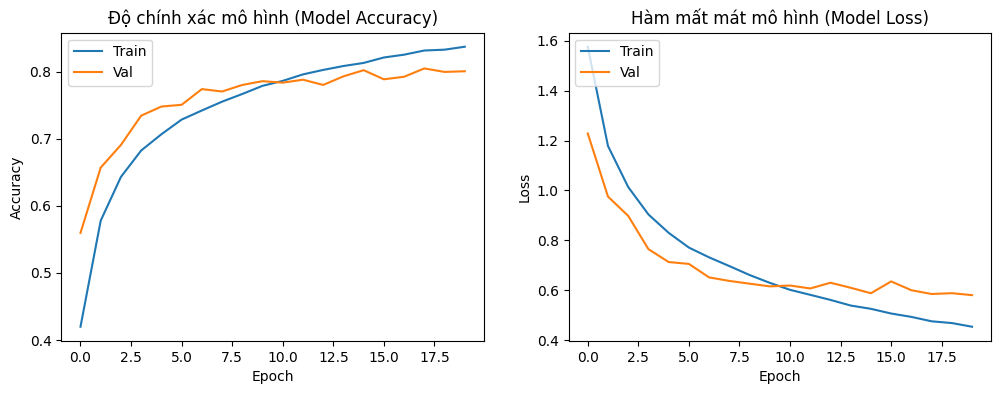

In [25]:
# Biểu đồ độ chính xác (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit_cifar10.history['accuracy'])
plt.plot(model_fit_cifar10.history['val_accuracy'])
plt.title('Độ chính xác mô hình (Model Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Biểu đồ hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit_cifar10.history['loss'])
plt.plot(model_fit_cifar10.history['val_loss'])
plt.title('Hàm mất mát mô hình (Model Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

### 6. Đánh giá mô hình trên tập kiểm tra (Test Set)

In [26]:
score_cifar10 = model_cifar10.evaluate(X_test, y_test_one_hot_cifar10, verbose=2)
print('\n--- KẾT QUẢ ĐÁNH GIÁ ---')
print('Test loss (Độ mất mát trên tập test):', score_cifar10[0])
print('Test accuracy (Độ chính xác trên tập test):', score_cifar10[1])

313/313 - 11s - 36ms/step - accuracy: 0.7939 - loss: 0.6224

--- KẾT QUẢ ĐÁNH GIÁ ---
Test loss (Độ mất mát trên tập test): 0.6223521828651428
Test accuracy (Độ chính xác trên tập test): 0.7939000129699707


### 7. Dự đoán nhãn cho ảnh sử dụng CNN

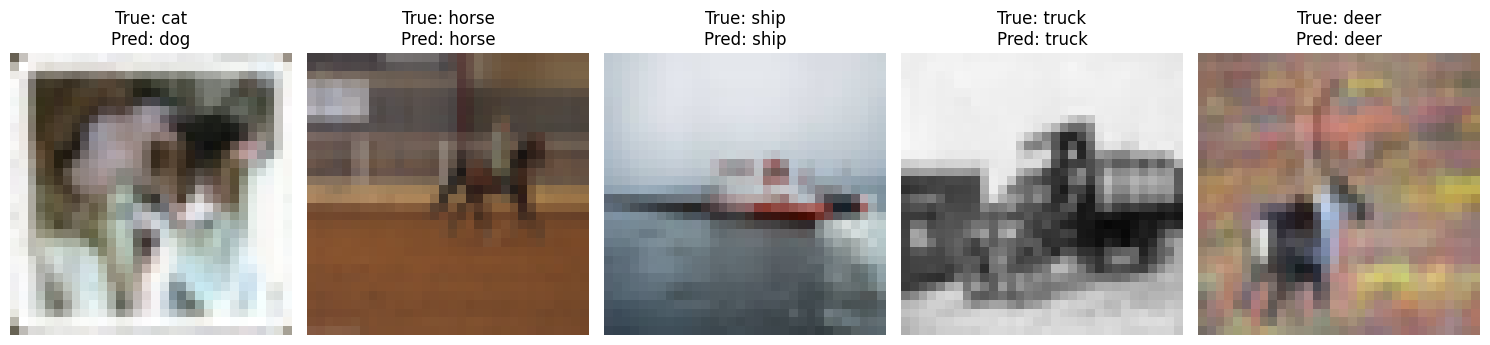

In [27]:
from random import randint

def display_prediction_cifar10(model, X_test_data, y_test_labels_one_hot, class_names, num_samples=5):
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        idx = randint(0, len(X_test_data) - 1)
        img = X_test_data[idx]
        true_label_idx = np.argmax(y_test_labels_one_hot[idx])

        # Reshape image for prediction (add batch dimension)
        img_reshaped = np.expand_dims(img, axis=0)
        prediction = model.predict(img_reshaped, verbose=0)
        predicted_label_idx = np.argmax(prediction)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true_label_idx]}\nPred: {class_names[predicted_label_idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Gọi hàm hiển thị dự đoán
display_prediction_cifar10(model_cifar10, X_test, y_test_one_hot_cifar10, class_names_cifar10, num_samples=5)

#Bài 2

## Nhận dạng ảnh Cat hoặc Dog với CNN

### 1. Nạp dữ liệu và Chuẩn hóa (Lấy ảnh Cat và Dog từ CIFAR-10)

In [28]:
# Tải bộ dữ liệu CIFAR-10
cifar10 = tf.keras.datasets.cifar10
(X_cifar_train_full, y_cifar_train_full), (X_cifar_test_full, y_cifar_test_full) = cifar10.load_data()

# Lọc dữ liệu chỉ lấy ảnh Cat (nhãn 3) và Dog (nhãn 5)
# CIFAR-10 class labels:
# 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer,
# 5: dog, 6: frog, 7: horse, 8: ship, 9: truck

cat_indices_train = np.where(y_cifar_train_full == 3)[0]
dog_indices_train = np.where(y_cifar_train_full == 5)[0]
cat_dog_indices_train = np.concatenate((cat_indices_train, dog_indices_train))

cat_indices_test = np.where(y_cifar_test_full == 3)[0]
dog_indices_test = np.where(y_cifar_test_full == 5)[0]
cat_dog_indices_test = np.concatenate((cat_indices_test, dog_indices_test))

X_train_cd = X_cifar_train_full[cat_dog_indices_train]
y_train_cd = y_cifar_train_full[cat_dog_indices_train]
X_test_cd = X_cifar_test_full[cat_dog_indices_test]
y_test_cd = y_cifar_test_full[cat_dog_indices_test]

# Chuyển đổi nhãn: Cat (3) thành 0, Dog (5) thành 1
y_train_cd = np.where(y_train_cd == 3, 0, 1)
y_test_cd = np.where(y_test_cd == 3, 0, 1)

print("Kích thước tập huấn luyện (Cat/Dog):", X_train_cd.shape, y_train_cd.shape)
print("Kích thước tập kiểm tra (Cat/Dog):", X_test_cd.shape, y_test_cd.shape)

# Chuẩn hóa giá trị pixel về đoạn [0, 1]
X_train_cd = X_train_cd.astype("float32") / 255.0
X_test_cd = X_test_cd.astype("float32") / 255.0

num_classes_cd = 2 # Chỉ có 2 lớp: Cat và Dog
input_shape_cd = X_train_cd.shape[1:] # (32, 32, 3)

# Chuyển nhãn thành One-Hot Encoding
y_train_one_hot_cd = keras.utils.to_categorical(y_train_cd, num_classes_cd)
y_test_one_hot_cd = keras.utils.to_categorical(y_test_cd, num_classes_cd)

Kích thước tập huấn luyện (Cat/Dog): (10000, 32, 32, 3) (10000, 1)
Kích thước tập kiểm tra (Cat/Dog): (2000, 32, 32, 3) (2000, 1)


### 2. Trực quan hóa dữ liệu (Xem thử một số ảnh Cat/Dog)

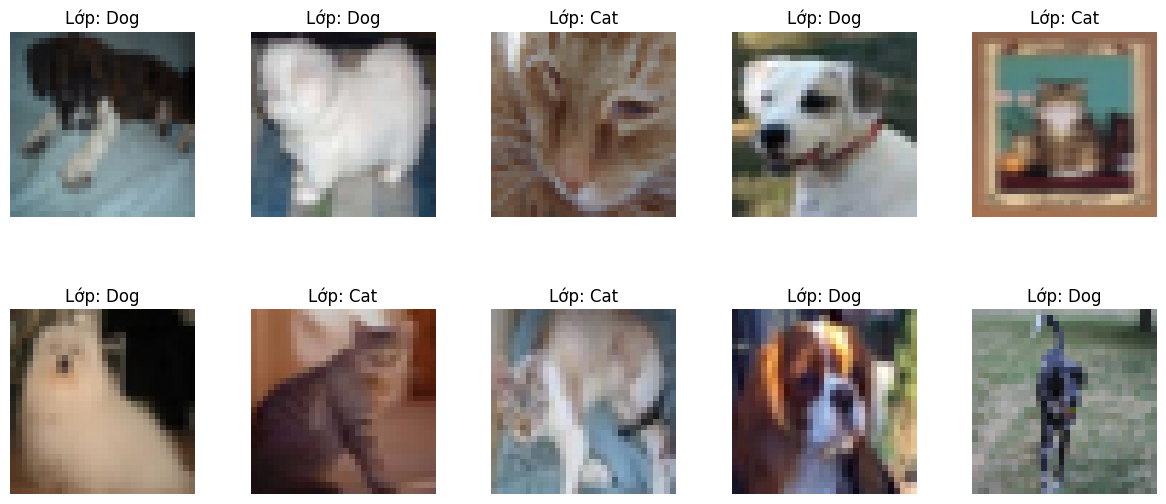

In [29]:
class_names_cd_labels = ['Cat', 'Dog'] # Tên hiển thị cho các lớp Cat và Dog

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax_cd = axes.ravel()

for i in range(10):
    idx = np.random.randint(0, len(X_train_cd))
    ax_cd[i].imshow(X_train_cd[idx])
    # y_train_cd[idx][0] lấy ra giá trị số nguyên của nhãn (0 hoặc 1)
    ax_cd[i].title.set_text(f"Lớp: {class_names_cd_labels[y_train_cd[idx][0]]}")
    ax_cd[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.show()

### 3. Xây dựng Kiến trúc mô hình CNN cho Cat/Dog

In [30]:
model_cat_dog_cnn = Sequential()
model_cat_dog_cnn.add(Input(shape=input_shape_cd))

# Tầng chập 1 & Max Pooling
model_cat_dog_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_cat_dog_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_cat_dog_cnn.add(MaxPool2D(pool_size=(2, 2)))
model_cat_dog_cnn.add(Dropout(0.25))

# Tầng chập 2 & Max Pooling
model_cat_dog_cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model_cat_dog_cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_cat_dog_cnn.add(MaxPool2D(pool_size=(2, 2)))
model_cat_dog_cnn.add(Dropout(0.25))

# Làm phẳng ma trận để đưa vào tầng kết nối đầy đủ (Fully Connected Layer)
model_cat_dog_cnn.add(Flatten())
model_cat_dog_cnn.add(Dense(units=256, activation='relu')) # Giảm số units so với CIFAR-10 full
model_cat_dog_cnn.add(Dropout(0.5))
model_cat_dog_cnn.add(Dense(units=num_classes_cd, activation='softmax')) # Softmax cho 2 lớp

# Hiển thị cấu trúc tóm tắt của mô hình
model_cat_dog_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,162 (2.50 MB)

 Trainable params: 656,162 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Cấu hình và Huấn luyện mô hình

In [31]:
model_cat_dog_cnn.compile(optimizer='adam',
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

# Thực hiện huấn luyện trong 25 epochs với kích thước lô (batch_size) là 64
model_fit_cat_dog_cnn = model_cat_dog_cnn.fit(X_train_cd, y_train_one_hot_cd,
                                              batch_size=64,
                                              epochs=25,
                                              validation_split=0.1,
                                              verbose=1)

Epoch 1/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 43s 288ms/step - accuracy: 0.5893 - loss: 0.6737 - val_accuracy: 0.5490 - val_loss: 0.6936
Epoch 2/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 284ms/step - accuracy: 0.6618 - loss: 0.6231 - val_accuracy: 0.6640 - val_loss: 0.5784
Epoch 3/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 283ms/step - accuracy: 0.6980 - loss: 0.5807 - val_accuracy: 0.6600 - val_loss: 0.5699
Epoch 4/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.7232 - loss: 0.5434 - val_accuracy: 0.6950 - val_loss: 0.5527
Epoch 5/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - accuracy: 0.7436 - loss: 0.5171 - val_accuracy: 0.5760 - val_loss: 0.7315
Epoch 6/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 39s 278ms/step - accuracy: 0.7671 - loss: 0.4818 - val_accuracy: 0.6710 - val_loss: 0.5949
Epoch 7/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 280ms/step - accuracy: 0.7843 - loss: 0.4559 - val_accuracy: 0.7250 - val_loss: 0.5258
Epoch 8/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.7896 - loss: 0

### 5. Trực quan hóa đồ thị Accuracy và Loss

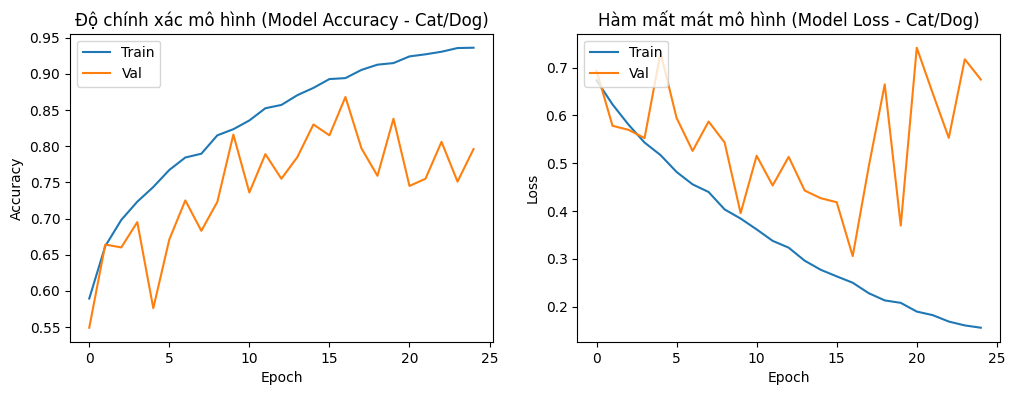

In [32]:
# Biểu đồ độ chính xác (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit_cat_dog_cnn.history['accuracy'])
plt.plot(model_fit_cat_dog_cnn.history['val_accuracy'])
plt.title('Độ chính xác mô hình (Model Accuracy - Cat/Dog)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Biểu đồ hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit_cat_dog_cnn.history['loss'])
plt.plot(model_fit_cat_dog_cnn.history['val_loss'])
plt.title('Hàm mất mát mô hình (Model Loss - Cat/Dog)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

### 6. Đánh giá mô hình trên tập kiểm tra (Test Set)

In [33]:
score_cat_dog_cnn = model_cat_dog_cnn.evaluate(X_test_cd, y_test_one_hot_cd, verbose=2)
print('\n--- KẾT QUẢ ĐÁNH GIÁ (Cat/Dog) ---')
print('Test loss (Độ mất mát trên tập test):', score_cat_dog_cnn[0])
print('Test accuracy (Độ chính xác trên tập test):', score_cat_dog_cnn[1])

63/63 - 3s - 47ms/step - accuracy: 0.8270 - loss: 0.5523

--- KẾT QUẢ ĐÁNH GIÁ (Cat/Dog) ---
Test loss (Độ mất mát trên tập test): 0.5523285865783691
Test accuracy (Độ chính xác trên tập test): 0.8270000219345093


### 7. Dự đoán nhãn cho ảnh sử dụng CNN

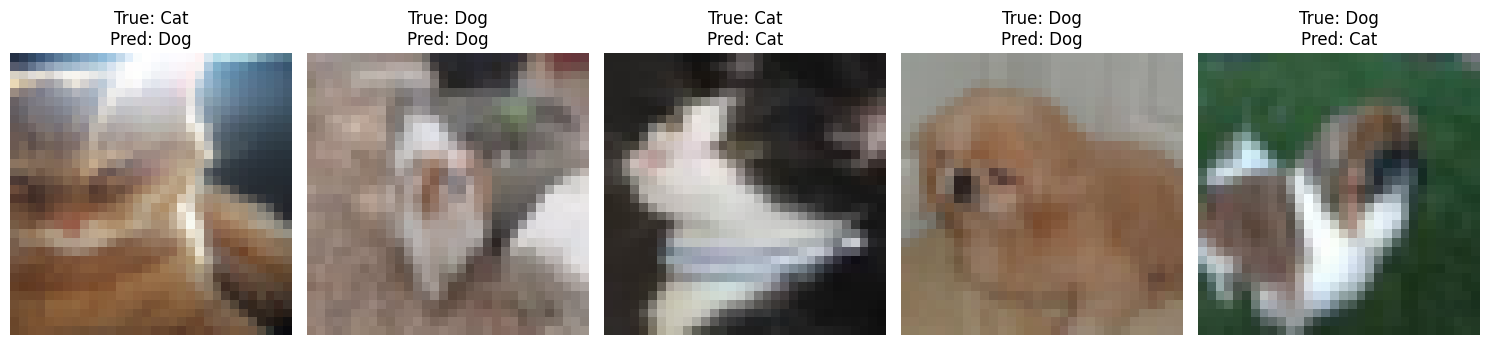

In [34]:
from random import randint

def display_prediction_cat_dog(model, X_test_data, y_test_labels_true, class_names, num_samples=5):
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        idx = randint(0, len(X_test_data) - 1)
        img = X_test_data[idx]
        true_label = y_test_labels_true[idx][0] # Lấy giá trị nhãn gốc (0 hoặc 1)

        # Reshape ảnh để dự đoán (thêm chiều batch)
        img_reshaped = np.expand_dims(img, axis=0)
        prediction = model.predict(img_reshaped, verbose=0)
        predicted_label = np.argmax(prediction)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Gọi hàm hiển thị dự đoán
display_prediction_cat_dog(model_cat_dog_cnn, X_test_cd, y_test_cd, class_names_cd_labels, num_samples=5)

#Bài 3

## Nhận dạng ảnh Fashion-MNIST với CNN

### 1. Nạp dữ liệu và Chuẩn hóa (Fashion-MNIST)

In [35]:
# Tải bộ dữ liệu Fashion-MNIST tích hợp sẵn trong TensorFlow
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_fmnist_train, y_fmnist_train), (X_fmnist_test, y_fmnist_test) = fashion_mnist.load_data()

print("Kích thước tập huấn luyện Fashion-MNIST:", X_fmnist_train.shape, y_fmnist_train.shape)
print("Kích thước tập kiểm tra Fashion-MNIST:", X_fmnist_test.shape, y_fmnist_test.shape)

# Tên của 10 lớp đối tượng trong bộ dữ liệu Fashion-MNIST
class_names_fmnist = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                      'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

num_classes_fmnist = 10
input_shape_fmnist = (28, 28, 1) # Ảnh xám kích thước 28x28 với 1 kênh màu

# Chuẩn hóa giá trị pixel từ đoạn [0, 255] về đoạn [0, 1]
X_fmnist_train = X_fmnist_train.astype("float32") / 255.0
X_fmnist_test = X_fmnist_test.astype("float32") / 255.0

# Reshape dữ liệu để phù hợp với input của Conv2D (thêm 1 chiều kênh màu)
X_fmnist_train = X_fmnist_train.reshape(X_fmnist_train.shape[0], 28, 28, 1)
X_fmnist_test = X_fmnist_test.reshape(X_fmnist_test.shape[0], 28, 28, 1)

# Chuyển giá trị nhãn từ số nguyên (0-9) thành cấu trúc One-Hot Encoding
y_fmnist_train_one_hot = keras.utils.to_categorical(y_fmnist_train, num_classes_fmnist)
y_fmnist_test_one_hot = keras.utils.to_categorical(y_fmnist_test, num_classes_fmnist)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện Fashion-MNIST: (60000, 28, 28) (60000,)
Kích thước tập kiểm tra Fashion-MNIST: (10000, 28, 28) (10000,)


### 2. Trực quan hóa dữ liệu (Xem thử 10 ảnh đầu tiên từ Fashion-MNIST)

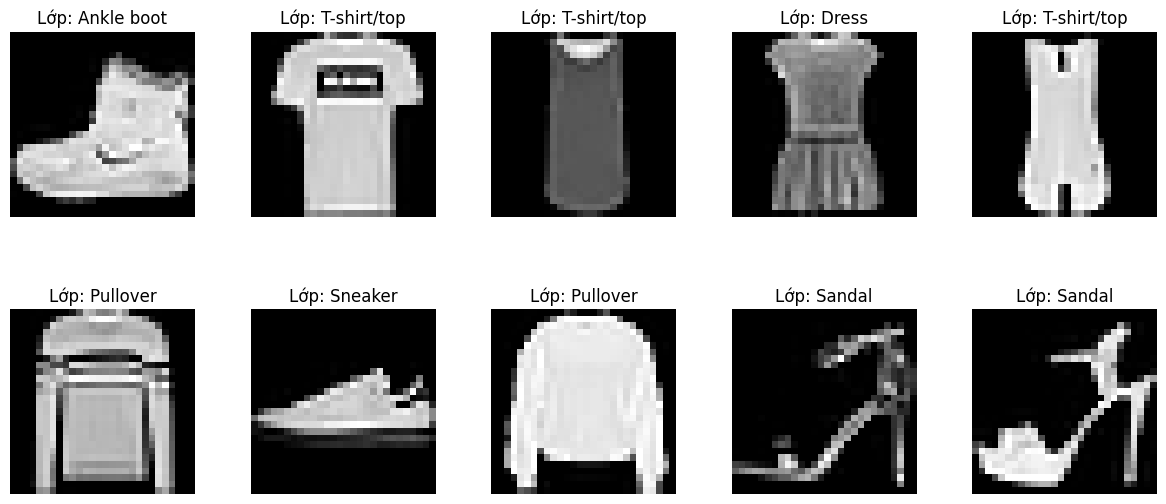

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax_fmnist = axes.ravel()

for i in range(10):
    ax_fmnist[i].imshow(X_fmnist_train[i].reshape(28, 28), cmap='gray') # Hiển thị ảnh xám
    ax_fmnist[i].title.set_text(f"Lớp: {class_names_fmnist[y_fmnist_train[i]]}")
    ax_fmnist[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.show()

### 3. Xây dựng Kiến trúc mô hình CNN cho Fashion-MNIST

In [37]:
model_fmnist_cnn = Sequential()
model_fmnist_cnn.add(Input(shape=input_shape_fmnist))

# Tầng chập 1 & Max Pooling
model_fmnist_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_fmnist_cnn.add(MaxPool2D(pool_size=(2, 2)))
model_fmnist_cnn.add(Dropout(0.25))

# Tầng chập 2 & Max Pooling
model_fmnist_cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model_fmnist_cnn.add(MaxPool2D(pool_size=(2, 2)))
model_fmnist_cnn.add(Dropout(0.25))

# Làm phẳng ma trận để đưa vào tầng kết nối đầy đủ
model_fmnist_cnn.add(Flatten())
model_fmnist_cnn.add(Dense(units=128, activation='relu')) # Số units phù hợp với Fashion-MNIST
model_fmnist_cnn.add(Dropout(0.5))
model_fmnist_cnn.add(Dense(units=num_classes_fmnist, activation='softmax')) # Softmax cho 10 lớp

# Hiển thị cấu trúc tóm tắt của mô hình
model_fmnist_cnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Cấu hình và Huấn luyện mô hình

In [38]:
model_fmnist_cnn.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

# Thực hiện huấn luyện trong 20 epochs với kích thước lô (batch_size) là 64
model_fit_fmnist_cnn = model_fmnist_cnn.fit(X_fmnist_train, y_fmnist_train_one_hot,
                                            batch_size=64,
                                            epochs=20,
                                            validation_split=0.1,
                                            verbose=1)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 92ms/step - accuracy: 0.7774 - loss: 0.6151 - val_accuracy: 0.8625 - val_loss: 0.3739
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.8541 - loss: 0.4073 - val_accuracy: 0.8862 - val_loss: 0.3078
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 78s 92ms/step - accuracy: 0.8727 - loss: 0.3554 - val_accuracy: 0.8947 - val_loss: 0.2901
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 92ms/step - accuracy: 0.8830 - loss: 0.3241 - val_accuracy: 0.9048 - val_loss: 0.2548
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.8912 - loss: 0.3046 - val_accuracy: 0.9055 - val_loss: 0.2505
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.8961 - loss: 0.2870 - val_accuracy: 0.9080 - val_loss: 0.2479
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 78s 92ms/step - accuracy: 0.8987 - loss: 0.2759 - val_accuracy: 0.9165 - val_loss: 0.2292
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.9019 - loss: 0.2648 - 

### 5. Trực quan hóa đồ thị Accuracy và Loss

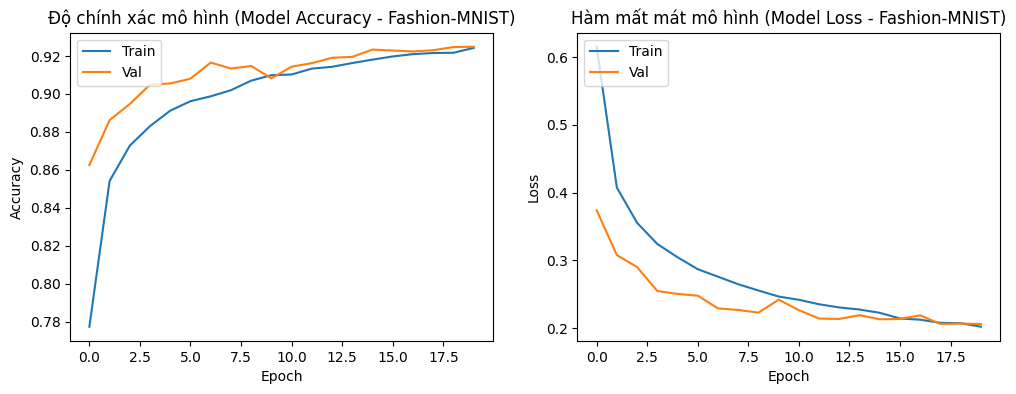

In [39]:
# Biểu đồ độ chính xác (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit_fmnist_cnn.history['accuracy'])
plt.plot(model_fit_fmnist_cnn.history['val_accuracy'])
plt.title('Độ chính xác mô hình (Model Accuracy - Fashion-MNIST)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Biểu đồ hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit_fmnist_cnn.history['loss'])
plt.plot(model_fit_fmnist_cnn.history['val_loss'])
plt.title('Hàm mất mát mô hình (Model Loss - Fashion-MNIST)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

### 6. Đánh giá mô hình trên tập kiểm tra (Test Set)

In [40]:
score_fmnist_cnn = model_fmnist_cnn.evaluate(X_fmnist_test, y_fmnist_test_one_hot, verbose=2)
print('\n--- KẾT QUẢ ĐÁNH GIÁ (Fashion-MNIST) ---')
print('Test loss (Độ mất mát trên tập test):', score_fmnist_cnn[0])
print('Test accuracy (Độ chính xác trên tập test):', score_fmnist_cnn[1])

313/313 - 4s - 11ms/step - accuracy: 0.9213 - loss: 0.2207

--- KẾT QUẢ ĐÁNH GIÁ (Fashion-MNIST) ---
Test loss (Độ mất mát trên tập test): 0.220735564827919
Test accuracy (Độ chính xác trên tập test): 0.9212999939918518


### 7. Dự đoán nhãn cho ảnh sử dụng CNN

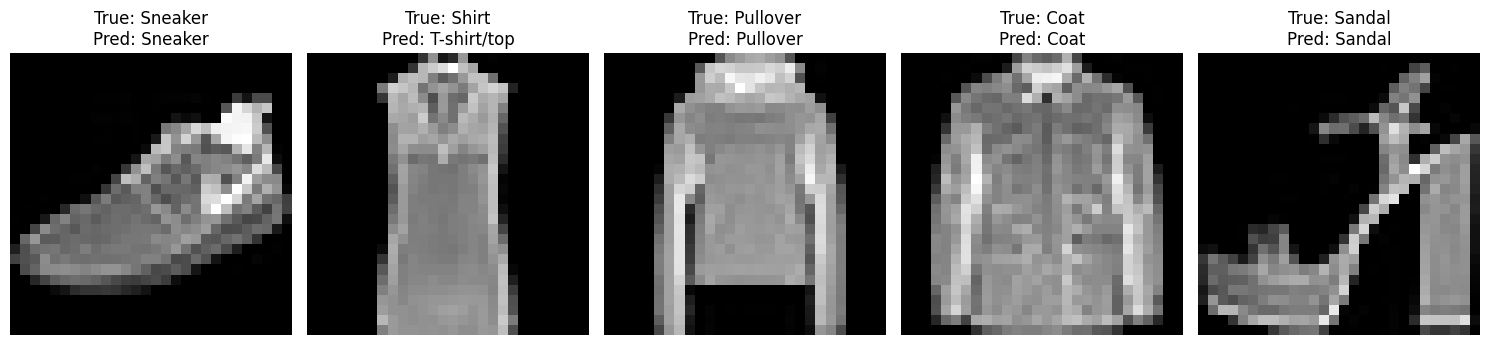

In [41]:
from random import randint

def display_prediction_fmnist(model, X_test_data, y_test_labels_true, class_names, num_samples=5):
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        idx = randint(0, len(X_test_data) - 1)
        img = X_test_data[idx]
        true_label = y_test_labels_true[idx] # Nhãn gốc là số nguyên

        # Reshape ảnh để dự đoán (thêm chiều batch)
        img_reshaped = np.expand_dims(img, axis=0)
        prediction = model.predict(img_reshaped, verbose=0)
        predicted_label = np.argmax(prediction)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img.reshape(28, 28), cmap='gray')
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Gọi hàm hiển thị dự đoán
display_prediction_fmnist(model_fmnist_cnn, X_fmnist_test, y_fmnist_test, class_names_fmnist, num_samples=5)